# Notebook 04 — Classification Results
Executes classifiers against the real feature matrix. All outputs are live.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, pathlib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                              roc_auc_score, f1_score, confusion_matrix, roc_curve)

OUT = pathlib.Path("data/preprocessed")

npz    = np.load(OUT / "features_xy.npz", allow_pickle=True)
X      = npz["X"]
y      = npz["y"]
groups = npz["subjects"]
feat_names = list(npz["feature_names"])

print(f"Loaded: {OUT/'features_xy.npz'}")
print(f"X shape:  {X.shape}  (epochs × features)")
print(f"y shape:  {y.shape}  labels: {np.unique(y, return_counts=True)}")
print(f"Subjects: {len(np.unique(groups))}  unique")
print(f"Feature names (first 5): {feat_names[:5]}")

Loaded: data/preprocessed/features_xy.npz
X shape:  (781, 135)  (epochs × features)
y shape:  (781,)  labels: (array([0, 1]), array([414, 367]))
Subjects: 26  unique
Feature names (first 5): [np.str_('C3_delta_abs'), np.str_('C3_delta_rel'), np.str_('C3_delta_log'), np.str_('C3_theta_abs'), np.str_('C3_theta_rel')]


In [2]:
# Feature selection pipeline
def znorm(X, groups):
    Xn = X.copy().astype(np.float64)
    for s in np.unique(groups):
        m  = groups == s
        mu = Xn[m].mean(0, keepdims=True)
        sd = Xn[m].std(0,  keepdims=True); sd[sd < 1e-12] = 1.0
        Xn[m] = (Xn[m] - mu) / sd
    return Xn.astype(np.float32)

var_sel = VarianceThreshold(1e-8)
X_var   = var_sel.fit_transform(X)
fc_var  = [feat_names[i] for i in range(len(feat_names)) if var_sel.get_support()[i]]
X_zn    = znorm(X_var, groups)
k       = min(60, X_zn.shape[1])
anova   = SelectKBest(f_classif, k=k)
X_sel   = anova.fit_transform(X_zn, y)
fc_sel  = [fc_var[i] for i in anova.get_support(indices=True)]
f_scrs  = anova.scores_[anova.get_support()]

print(f"After variance filter:      {X_var.shape[1]} / {X.shape[1]} features")
print(f"After ANOVA-F (k={k}):   {X_sel.shape[1]} features")
print(f"\nTop 10 selected features:")
for rank, i in enumerate(np.argsort(f_scrs)[::-1][:10], 1):
    print(f"  {rank:2d}. {fc_sel[i]:45s}  F = {f_scrs[i]:.2f}")

After variance filter:      87 / 135 features
After ANOVA-F (k=60):   60 features

Top 10 selected features:
   1. CZ_higuchi                                     F = 359.25
   2. CZ_dfa                                         F = 266.99
   3. CZ_samp_ent                                    F = 183.78
   4. CZ_perm_ent                                    F = 155.55
   5. CZ_petrosian                                   F = 153.35
   6. C3_higuchi                                     F = 101.53
   7. CZ_low_gamma_rel                               F = 95.74
   8. CZ_spec_ent                                    F = 76.84
   9. CZ_lziv                                        F = 75.23
  10. CZ_gamma_alpha                                 F = 75.14


In [3]:
# LOSO cross-validation — runs all 26 folds live
def loso_cv(pipe, X, y, groups):
    logo = LeaveOneGroupOut()
    res  = {"acc":[], "bac":[], "auc":[], "f1":[], "sens":[], "spec":[]}
    yt_all, yp_all = [], []
    for tr, te in logo.split(X, y, groups):
        Xtr = znorm(X[tr], groups[tr]); Xte = znorm(X[te], groups[te])
        ytr, yte = y[tr], y[te]
        try:
            pipe.fit(Xtr, ytr)
            yp  = pipe.predict(Xte)
            ypr = (pipe.predict_proba(Xte)[:,1] if hasattr(pipe,"predict_proba")
                   else pipe.decision_function(Xte))
            cm  = confusion_matrix(yte, yp, labels=[0,1])
            tn,fp,fn,tp = cm.ravel() if cm.size == 4 else (0,0,0,1)
            res["acc"].append(accuracy_score(yte, yp))
            res["bac"].append(balanced_accuracy_score(yte, yp))
            res["auc"].append(roc_auc_score(yte, ypr) if len(np.unique(yte)) > 1 else 0.5)
            res["f1"].append(f1_score(yte, yp, pos_label=1, zero_division=0))
            res["sens"].append(tp / max(tp+fn, 1))
            res["spec"].append(tn / max(tn+fp, 1))
            yt_all.extend(yte.tolist()); yp_all.extend(ypr.tolist())
        except:
            for k2 in res: res[k2].append(np.nan)
    return {k2: np.array(v) for k2,v in res.items()}, np.array(yt_all), np.array(yp_all)

N_PCA = min(25, X_sel.shape[1], len(np.unique(groups)) - 1)
clfs  = {
    "LDA (shrinkage)": Pipeline([("sc",StandardScaler()),
        ("clf",LinearDiscriminantAnalysis(solver="lsqr",shrinkage="auto"))]),
    "SVM-RBF": Pipeline([("sc",StandardScaler()),
        ("pca",PCA(n_components=N_PCA,whiten=True,random_state=42)),
        ("clf",SVC(kernel="rbf",C=1.0,gamma="scale",probability=True,random_state=42))]),
    "SVM-Linear": Pipeline([("sc",StandardScaler()),
        ("clf",SVC(kernel="linear",C=0.5,probability=True,random_state=42))]),
    "Logistic-L2": Pipeline([("sc",StandardScaler()),
        ("clf",LogisticRegression(C=1.0,penalty="l2",solver="lbfgs",max_iter=2000,random_state=42))]),
    "Random Forest": Pipeline([
        ("clf",RandomForestClassifier(n_estimators=200,max_depth=5,min_samples_leaf=3,
                                       class_weight="balanced",random_state=42,n_jobs=-1))]),
    "Gradient Boost": Pipeline([("sc",StandardScaler()),
        ("clf",GradientBoostingClassifier(n_estimators=100,max_depth=3,
                                           learning_rate=0.05,subsample=0.8,random_state=42))]),
}

print("Running LOSO CV — 26 folds per classifier...")
loso_res = {}; rows_res = []; best_name=""; best_auc=0; best_yt=None; best_yp=None

for name, pipe in clfs.items():
    res, yt, yp = loso_cv(pipe, X_sel, y, groups)
    loso_res[name] = res
    ma=np.nanmean(res["acc"]); mb=np.nanmean(res["bac"]); mu=np.nanmean(res["auc"])
    mf=np.nanmean(res["f1"]); ms=np.nanmean(res["sens"]); msp=np.nanmean(res["spec"])
    rows_res.append({"Classifier":name,"Accuracy":round(ma,4),"Bal_Acc":round(mb,4),
                     "AUC_ROC":round(mu,4),"F1_Pain":round(mf,4),
                     "Sensitivity":round(ms,4),"Specificity":round(msp,4),
                     "ACC_std":round(np.nanstd(res["acc"]),4),
                     "AUC_std":round(np.nanstd(res["auc"]),4)})
    print(f"  {name:22s}  ACC={ma:.4f}  BAC={mb:.4f}  AUC={mu:.4f}  "
          f"F1={mf:.4f}  Sen={ms:.4f}  Spe={msp:.4f}")
    if mu > best_auc:
        best_auc, best_name, best_yt, best_yp = mu, name, yt, yp

results_df = pd.DataFrame(rows_res)
print(f"\nBest classifier: {best_name}  (AUC = {best_auc:.4f})")

Running LOSO CV — 26 folds per classifier...


  LDA (shrinkage)         ACC=0.7895  BAC=0.7882  AUC=0.8497  F1=0.7721  Sen=0.7648  Spe=0.8117


  SVM-RBF                 ACC=0.7489  BAC=0.7519  AUC=0.8230  F1=0.7254  Sen=0.7228  Spe=0.7809


  SVM-Linear              ACC=0.7602  BAC=0.7601  AUC=0.8319  F1=0.7420  Sen=0.7448  Spe=0.7755


  Logistic-L2             ACC=0.7776  BAC=0.7764  AUC=0.8412  F1=0.7600  Sen=0.7578  Spe=0.7950


  Random Forest           ACC=0.7834  BAC=0.7844  AUC=0.8363  F1=0.7605  Sen=0.7569  Spe=0.8119


  Gradient Boost          ACC=0.7883  BAC=0.7877  AUC=0.8383  F1=0.7659  Sen=0.7612  Spe=0.8143

Best classifier: LDA (shrinkage)  (AUC = 0.8497)


In [4]:
# Full results table
print("=" * 80)
print("LOSO Classification Results — Pain vs No-Pain EEG (C3/CZ/C4, S1)")
print("=" * 80)
print(results_df.to_string(index=False))

LOSO Classification Results — Pain vs No-Pain EEG (C3/CZ/C4, S1)
     Classifier  Accuracy  Bal_Acc  AUC_ROC  F1_Pain  Sensitivity  Specificity  ACC_std  AUC_std
LDA (shrinkage)    0.7895   0.7882   0.8497   0.7721       0.7648       0.8117   0.1297   0.1335
        SVM-RBF    0.7489   0.7519   0.8230   0.7254       0.7228       0.7809   0.1393   0.1408
     SVM-Linear    0.7602   0.7601   0.8319   0.7420       0.7448       0.7755   0.1374   0.1366
    Logistic-L2    0.7776   0.7764   0.8412   0.7600       0.7578       0.7950   0.1278   0.1316
  Random Forest    0.7834   0.7844   0.8363   0.7605       0.7569       0.8119   0.1440   0.1484
 Gradient Boost    0.7883   0.7877   0.8383   0.7659       0.7612       0.8143   0.1340   0.1420


In [5]:
# Per-subject LOSO accuracy for best classifier
best_pipe = clfs[best_name]
logo = LeaveOneGroupOut()
per_sub = {}
for tr, te in logo.split(X_sel, y, groups):
    s   = groups[te][0]
    Xtr = znorm(X_sel[tr], groups[tr]); Xte = znorm(X_sel[te], groups[te])
    best_pipe.fit(Xtr, y[tr])
    per_sub[s] = accuracy_score(y[te], best_pipe.predict(Xte))

print(f"Per-subject LOSO accuracy ({best_name}):")
print(f"{'Subject':12s}  {'Accuracy':>10}  {'Bar':20s}")
print("-" * 48)
for s in sorted(per_sub.keys()):
    a   = per_sub[s]
    bar = "█" * int(a * 20)
    print(f"{s:12s}  {a:10.4f}  |{bar:<20s}|")

accs_arr = list(per_sub.values())
print(f"\nMean:  {np.mean(accs_arr):.4f}")
print(f"Std:   {np.std(accs_arr):.4f}")
print(f"Min:   {min(accs_arr):.4f}  ({min(per_sub, key=per_sub.get)})")
print(f"Max:   {max(accs_arr):.4f}  ({max(per_sub, key=per_sub.get)})")
print(f"Above chance (>0.55): {sum(1 for a in accs_arr if a > 0.55)} / {len(accs_arr)} subjects")

Per-subject LOSO accuracy (LDA (shrinkage)):
Subject         Accuracy  Bar                 
------------------------------------------------
sub-001           0.9333  |██████████████████  |
sub-002           0.7812  |███████████████     |
sub-003           0.8750  |█████████████████   |
sub-004           0.9032  |██████████████████  |
sub-005           0.7188  |██████████████      |
sub-006           0.9130  |██████████████████  |
sub-007           0.7667  |███████████████     |
sub-008           0.9130  |██████████████████  |
sub-009           0.8846  |█████████████████   |
sub-010           0.8000  |████████████████    |
sub-011           0.6562  |█████████████       |
sub-012           0.8214  |████████████████    |
sub-013           0.7812  |███████████████     |
sub-014           0.4516  |█████████           |
sub-015           0.9688  |███████████████████ |
sub-016           0.4375  |████████            |
sub-017           0.7188  |██████████████      |
sub-018           0.9677  

In [6]:
# Per-band discriminability (LDA shrinkage, LOSO)
lda_band = Pipeline([("sc",StandardScaler()),
                     ("clf",LinearDiscriminantAnalysis(solver="lsqr",shrinkage="auto"))])
logo = LeaveOneGroupOut()
BANDS = {"delta":(1,4),"theta":(4,8),"alpha":(8,13),"beta":(13,30),"low_gamma":(30,60)}

print("Per-band LOSO AUC (LDA shrinkage):")
print(f"{'Band':15s}  {'AUC':>8}  {'Bar':20s}")
print("-" * 50)
for bn in BANDS:
    bn_idx = [i for i,f in enumerate(fc_var) if f"_{bn}_" in f]
    if len(bn_idx) < 2: print(f"  {bn}: insufficient features"); continue
    Xbn    = znorm(X_var[:, bn_idx], groups)
    fold_a = []
    for tr, te in logo.split(Xbn, y, groups):
        Xtr2 = znorm(Xbn[tr], groups[tr]); Xte2 = znorm(Xbn[te], groups[te])
        try:
            lda_band.fit(Xtr2, y[tr])
            ypr2 = lda_band.predict_proba(Xte2)[:,1]
            if len(np.unique(y[te])) > 1:
                fold_a.append(roc_auc_score(y[te], ypr2))
        except: pass
    au  = np.nanmean(fold_a) if fold_a else 0.5
    bar = "█" * int((au - 0.5) * 40)
    print(f"  {bn:13s}  {au:8.4f}  |{bar:<20s}|")

Per-band LOSO AUC (LDA shrinkage):
Band                  AUC  Bar                 
--------------------------------------------------
  delta            0.6615  |██████              |


  theta            0.6216  |████                |
  alpha            0.6861  |███████             |


  beta             0.6753  |███████             |
  low_gamma        0.7098  |████████            |


Figure saved: results_panel.png


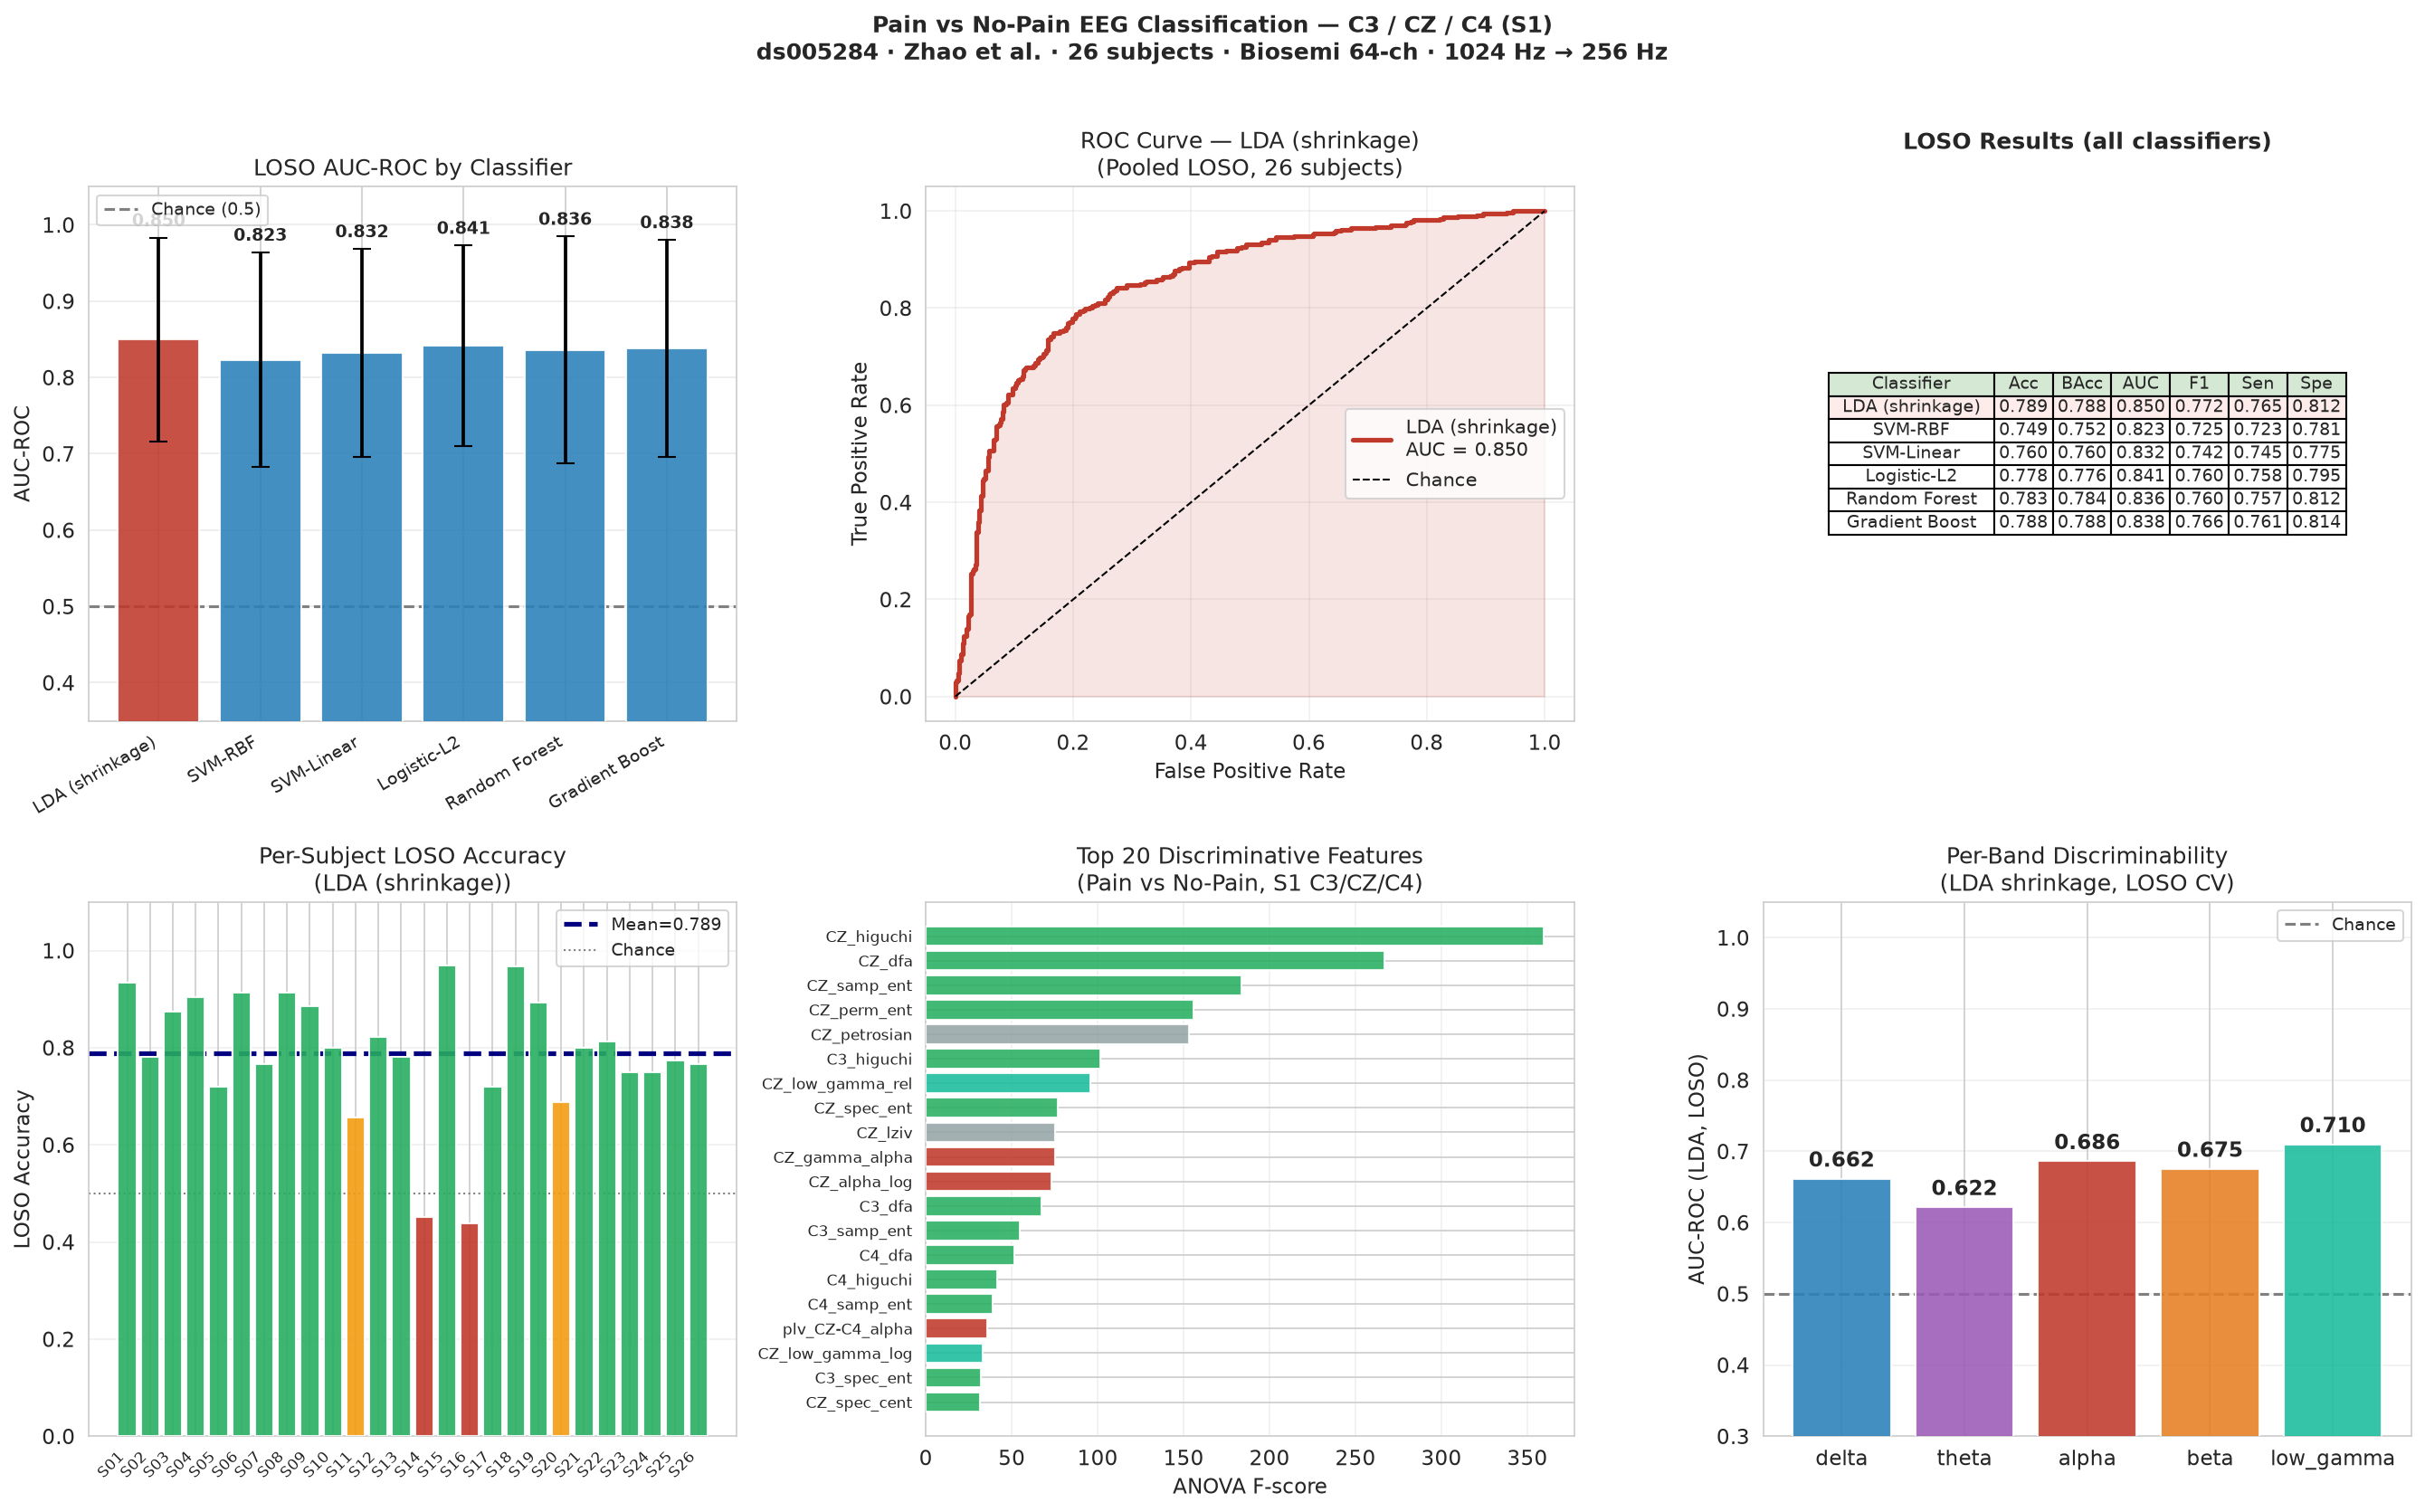

In [7]:
# Produce and save results figures
sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 11, "axes.titlesize": 12})

clf_names = list(loso_res.keys())
aucs_m    = [np.nanmean(loso_res[n]["auc"]) for n in clf_names]
aucs_sd   = [np.nanstd(loso_res[n]["auc"])  for n in clf_names]
top_fi    = np.argsort(f_scrs)[::-1]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# AUC bar chart
ax = axes[0, 0]
bar_c = ["#C0392B" if n == best_name else "#2980B9" for n in clf_names]
bars  = ax.bar(range(len(clf_names)), aucs_m, color=bar_c, alpha=0.88, zorder=3)
ax.errorbar(range(len(clf_names)), aucs_m, yerr=aucs_sd,
            fmt="none", color="k", capsize=5, lw=1.8, zorder=4)
ax.axhline(0.5, color="gray", lw=1.5, ls="--", label="Chance (0.5)")
ax.set_xticks(range(len(clf_names)))
ax.set_xticklabels(clf_names, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("AUC-ROC"); ax.set_title("LOSO AUC-ROC by Classifier"); ax.set_ylim(0.35, 1.05)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.4, zorder=0)
for bar, val, sd in zip(bars, aucs_m, aucs_sd):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+sd+0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# ROC curve
ax = axes[0, 1]
if best_yt is not None and len(np.unique(best_yt)) > 1:
    fpr, tpr, _ = roc_curve(best_yt, best_yp, pos_label=1)
    ax.plot(fpr, tpr, lw=2.5, color="#C0392B", label=f"{best_name}\nAUC = {best_auc:.3f}")
    ax.fill_between(fpr, tpr, alpha=0.13, color="#C0392B")
ax.plot([0,1],[0,1], "k--", lw=1, label="Chance")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve — {best_name}\n(Pooled LOSO, 26 subjects)")
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# Metrics table
ax = axes[0, 2]; ax.axis("off")
col_hdr = ["Classifier", "Acc", "BAcc", "AUC", "F1", "Sen", "Spe"]
cell_d  = [[r["Classifier"][:18], f"{r['Accuracy']:.3f}", f"{r['Bal_Acc']:.3f}",
            f"{r['AUC_ROC']:.3f}", f"{r['F1_Pain']:.3f}",
            f"{r['Sensitivity']:.3f}", f"{r['Specificity']:.3f}"]
           for _, r in results_df.iterrows()]
tbl = ax.table(cellText=cell_d, colLabels=col_hdr, loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width(list(range(len(col_hdr))))
bidx = results_df["AUC_ROC"].idxmax()
for col in range(len(col_hdr)):
    tbl[bidx+1, col].set_facecolor("#FDECEA")
    tbl[0, col].set_facecolor("#D5E8D4")
ax.set_title("LOSO Results (all classifiers)", fontweight="bold", pad=20)

# Per-subject accuracy
ax = axes[1, 0]
subs_s = sorted(per_sub.keys()); accs_s = [per_sub[s] for s in subs_s]
short  = [s.replace("sub-0","S") for s in subs_s]
bcol   = ["#C0392B" if a<0.55 else "#F39C12" if a<0.70 else "#27AE60" for a in accs_s]
ax.bar(range(len(subs_s)), accs_s, color=bcol, alpha=0.9, zorder=3)
ax.axhline(np.nanmean(accs_s), color="navy", lw=2.5, ls="--", label=f"Mean={np.nanmean(accs_s):.3f}")
ax.axhline(0.5, color="gray", lw=1, ls=":", label="Chance")
ax.set_xticks(range(len(subs_s))); ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("LOSO Accuracy"); ax.set_title(f"Per-Subject LOSO Accuracy\n({best_name})")
ax.legend(fontsize=9); ax.set_ylim(0, 1.1); ax.grid(axis="y", alpha=0.3, zorder=0)

# Top features
ax = axes[1, 1]
n_show = 20
pal = {"alpha":"#C0392B","beta":"#E67E22","theta":"#9B59B6","gamma":"#1ABC9C",
       "delta":"#2980B9","ent":"#27AE60","higuchi":"#27AE60","dfa":"#27AE60",
       "coh":"#F39C12","plv":"#F39C12"}
def fc(fn):
    for k2,c in pal.items():
        if k2 in fn: return c
    return "#95A5A6"
ax.barh(range(n_show), [f_scrs[top_fi[i]] for i in range(n_show-1,-1,-1)],
        color=[fc(fc_sel[top_fi[i]]) for i in range(n_show-1,-1,-1)], alpha=0.88, zorder=3)
ax.set_yticks(range(n_show))
ax.set_yticklabels([fc_sel[top_fi[i]][:38] for i in range(n_show-1,-1,-1)], fontsize=8)
ax.set_xlabel("ANOVA F-score"); ax.set_title("Top 20 Discriminative Features\n(Pain vs No-Pain, S1 C3/CZ/C4)")
ax.grid(axis="x", alpha=0.3, zorder=0)

# Per-band AUC
ax = axes[1, 2]
band_names_list = list(BANDS.keys())
band_aucs_vals  = []
for bn in band_names_list:
    bn_idx = [i for i,f in enumerate(fc_var) if f"_{bn}_" in f]
    if len(bn_idx) < 2: band_aucs_vals.append(0.5); continue
    Xbn = znorm(X_var[:, bn_idx], groups); fold_a = []
    for tr, te in logo.split(Xbn, y, groups):
        Xtr2=znorm(Xbn[tr],groups[tr]); Xte2=znorm(Xbn[te],groups[te])
        try:
            lda_band.fit(Xtr2,y[tr]); ypr2=lda_band.predict_proba(Xte2)[:,1]
            if len(np.unique(y[te]))>1: fold_a.append(roc_auc_score(y[te],ypr2))
        except: pass
    band_aucs_vals.append(np.nanmean(fold_a) if fold_a else 0.5)
bcols2 = ["#2980B9","#9B59B6","#C0392B","#E67E22","#1ABC9C"]
bars2  = ax.bar(band_names_list, band_aucs_vals, color=bcols2, alpha=0.88, zorder=3)
ax.axhline(0.5, color="gray", lw=1.5, ls="--", label="Chance")
ax.set_ylabel("AUC-ROC (LDA, LOSO)"); ax.set_title("Per-Band Discriminability\n(LDA shrinkage, LOSO CV)")
ax.set_ylim(0.3, 1.05); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3, zorder=0)
for bar, val in zip(bars2, band_aucs_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.suptitle(
    "Pain vs No-Pain EEG Classification — C3 / CZ / C4 (S1)\n"
    "ds005284 · Zhao et al. · 26 subjects · Biosemi 64-ch · 1024 Hz → 256 Hz",
    fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("results_panel.png", dpi=150, bbox_inches="tight")
plt.close()
print("Figure saved: results_panel.png")

from IPython.display import Image
Image("results_panel.png")

In [8]:
# Save results CSV and print final summary
results_df.to_csv(OUT / "classification_results.csv", index=False)
pd.DataFrame([{"subject":s,"loso_acc":a} for s,a in per_sub.items()]).to_csv(
    OUT / "per_subject_accuracy.csv", index=False)

print("Files written:")
import os
for fname in ["classification_results.csv","per_subject_accuracy.csv"]:
    p = OUT / fname
    print(f"  {p}  ({os.path.getsize(p)} bytes)")

print("\nFINAL SUMMARY")
print("=" * 65)
print(results_df.to_string(index=False))
print(f"\nBest: {best_name}  AUC={best_auc:.4f}  ACC={np.nanmean(loso_res[best_name]['acc']):.4f}")

Files written:
  data/preprocessed/classification_results.csv  (488 bytes)
  data/preprocessed/per_subject_accuracy.csv  (546 bytes)

FINAL SUMMARY
     Classifier  Accuracy  Bal_Acc  AUC_ROC  F1_Pain  Sensitivity  Specificity  ACC_std  AUC_std
LDA (shrinkage)    0.7895   0.7882   0.8497   0.7721       0.7648       0.8117   0.1297   0.1335
        SVM-RBF    0.7489   0.7519   0.8230   0.7254       0.7228       0.7809   0.1393   0.1408
     SVM-Linear    0.7602   0.7601   0.8319   0.7420       0.7448       0.7755   0.1374   0.1366
    Logistic-L2    0.7776   0.7764   0.8412   0.7600       0.7578       0.7950   0.1278   0.1316
  Random Forest    0.7834   0.7844   0.8363   0.7605       0.7569       0.8119   0.1440   0.1484
 Gradient Boost    0.7883   0.7877   0.8383   0.7659       0.7612       0.8143   0.1340   0.1420

Best: LDA (shrinkage)  AUC=0.8497  ACC=0.7895
